<a href="https://colab.research.google.com/github/PoserioJed/POSERIO_CCMACLRL_EXERCISES/blob/main/Copy_of_Exercise3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 3

Use logistic regression to predict the probability of a passenger surviving.

https://www.kaggle.com/competitions/titanic/overview

In [35]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from seaborn import load_dataset
from sklearn.metrics import ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')


## Dataset File

In [36]:
dataset_url = 'https://github.com/robitussin/CCMACLRL_EXERCISES_OLD/blob/f5fdfba1aabbbafcf2fe49ca6e1c8f92f69d1458/datasets/titanic/train.csv?raw=true'
df = pd.read_csv(dataset_url)

## Test File

In [37]:
test_url = 'https://github.com/robitussin/CCMACLRL_EXERCISES_OLD/blob/f5fdfba1aabbbafcf2fe49ca6e1c8f92f69d1458/datasets/titanic/test.csv?raw=true'
dt=pd.read_csv(test_url)

In [38]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [39]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [40]:
df.dropna(inplace=True)

In [41]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


## Sample Submission File

In [64]:
sample_submission_url ='https://github.com/robitussin/CCMACLRL_EXERCISES_OLD/blob/f5fdfba1aabbbafcf2fe49ca6e1c8f92f69d1458/datasets/titanic/gender_submission.csv?raw=true'

sf=pd.read_csv(sample_submission_url)

In [65]:
sf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   PassengerId  418 non-null    int64
 1   Survived     418 non-null    int64
dtypes: int64(2)
memory usage: 6.7 KB


In [66]:
from sklearn.model_selection import train_test_split

x = df.drop('Survived', axis=1)
y = df['Survived']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=0)

In [67]:
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer


x_train_numeric = x_train.drop(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], axis=1)


imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
x_train_numeric_imputed = imputer.fit_transform(x_train_numeric)

model = LogisticRegression(random_state=0)
model.fit(x_train_numeric_imputed, y_train)

LogisticRegression(random_state=0)

In [68]:
from sklearn.impute import SimpleImputer


x_test_numeric = x_test.drop(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], axis=1)


imputer_test = SimpleImputer(missing_values=np.nan, strategy='mean')
imputer_test.fit(x_train_numeric)
x_test_numeric_imputed = imputer_test.transform(x_test_numeric)

model.score(x_test_numeric_imputed, y_test)

0.7027027027027027

In [69]:
from sklearn.metrics import confusion_matrix


x_test_numeric = x_test.drop(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], axis=1)


imputer_test = SimpleImputer(missing_values=np.nan, strategy='mean')
imputer_test.fit(x_train_numeric)
x_test_numeric_imputed = imputer_test.transform(x_test_numeric)


y_predicted = model.predict(x_test_numeric_imputed)
confusion_matrix(y_test, y_predicted)

array([[ 4,  8],
       [ 3, 22]])

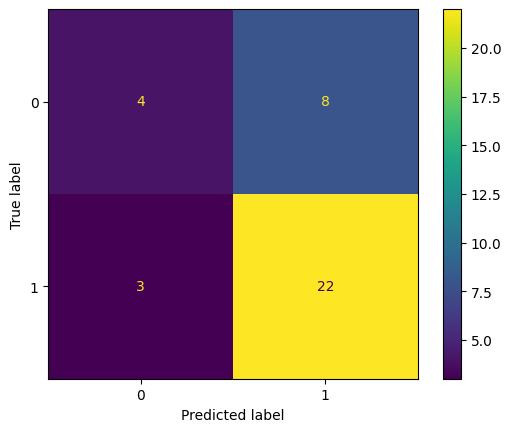

In [70]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_predicted)

## Generate Results

In [63]:
from sklearn.impute import SimpleImputer


dt_numeric = dt.drop(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], axis=1)


imputer_dt = SimpleImputer(missing_values=np.nan, strategy='mean')
imputer_dt.fit(x_train_numeric)
dt_numeric_imputed = imputer_dt.transform(dt_numeric)


id = dt['PassengerId']
y_pred = model.predict(dt_numeric_imputed)

submission_df = pd.DataFrame({
    'PassengerId': id,
    'Survived': y_pred
})

submission_df.to_csv('submission_file.csv', index=False)
print("Submission file created: submission_file.csv")

Submission file created: submission_file.csv
